In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r'D:\Data Analytics\sales_analysis\dataset\sales_clean_data.xlsx' , sheet_name='Sales Data')
df.head(5)

,order_id,year,month,order_date,ship_date,ship_mode,customer_id,customer_name,client_segment,country,...,product_name,sales_price,quantity,discount,total_sales_amount,purchasing_price,total_purchasing_amounts,net_profit,shipping_days,profit_margin_%
0,CA-2016-152156,2016,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Bush Somerset Collection Bookcase,261.9600,2,0.0,523.9200,157.17600,314.35200,209.56800,3,40.0
1,CA-2016-152156,2016,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.0,2195.8200,402.56700,1207.70100,988.11900,3,45.0
2,CA-2016-138688,2016,Jun,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.0,29.2400,8.77200,17.54400,11.69600,4,40.0
3,US-2015-108966,2015,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.0,4787.8875,478.78875,2393.94375,2393.94375,7,50.0
4,US-2015-108966,2015,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.2,35.7888,11.18400,22.36800,13.42080,7,37.5


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
year,1006.0,2015.656064,2014.0,2015.0,2016.0,2017.0,2017.0,1.109434
order_date,1006,2016-04-04 22:35:32.803180800,2014-01-04 00:00:00,2015-04-26 00:00:00,2016-05-30 00:00:00,2017-04-07 00:00:00,2017-12-30 00:00:00,NaN
ship_date,1006,2016-04-08 22:49:51.650099456,2014-01-08 00:00:00,2015-05-02 00:00:00,2016-06-04 00:00:00,2017-04-11 00:00:00,2018-01-05 00:00:00,NaN
postal_code,1006.0,53709.311133,1841.0,19308.5,51461.5,85254.0,98661.0,31699.374286
sales_price,1006.0,238.360934,1.08,18.498,55.49,209.9175,8159.952,595.524062
quantity,1006.0,3.808151,1.0,2.0,3.0,5.0,14.0,2.272477
discount,1006.0,0.079016,0.0,0.0,0.0,0.2,0.32,0.099007
total_sales_amount,1006.0,1109.855877,1.68,44.9052,162.72,731.2866,65279.616,3658.377546
purchasing_price,1006.0,143.664889,0.648,11.1022,33.215,121.8003,5303.9688,360.031046
total_purchasing_amounts,1006.0,719.546625,0.924,29.504,113.476,485.603125,42431.7504,2280.609856


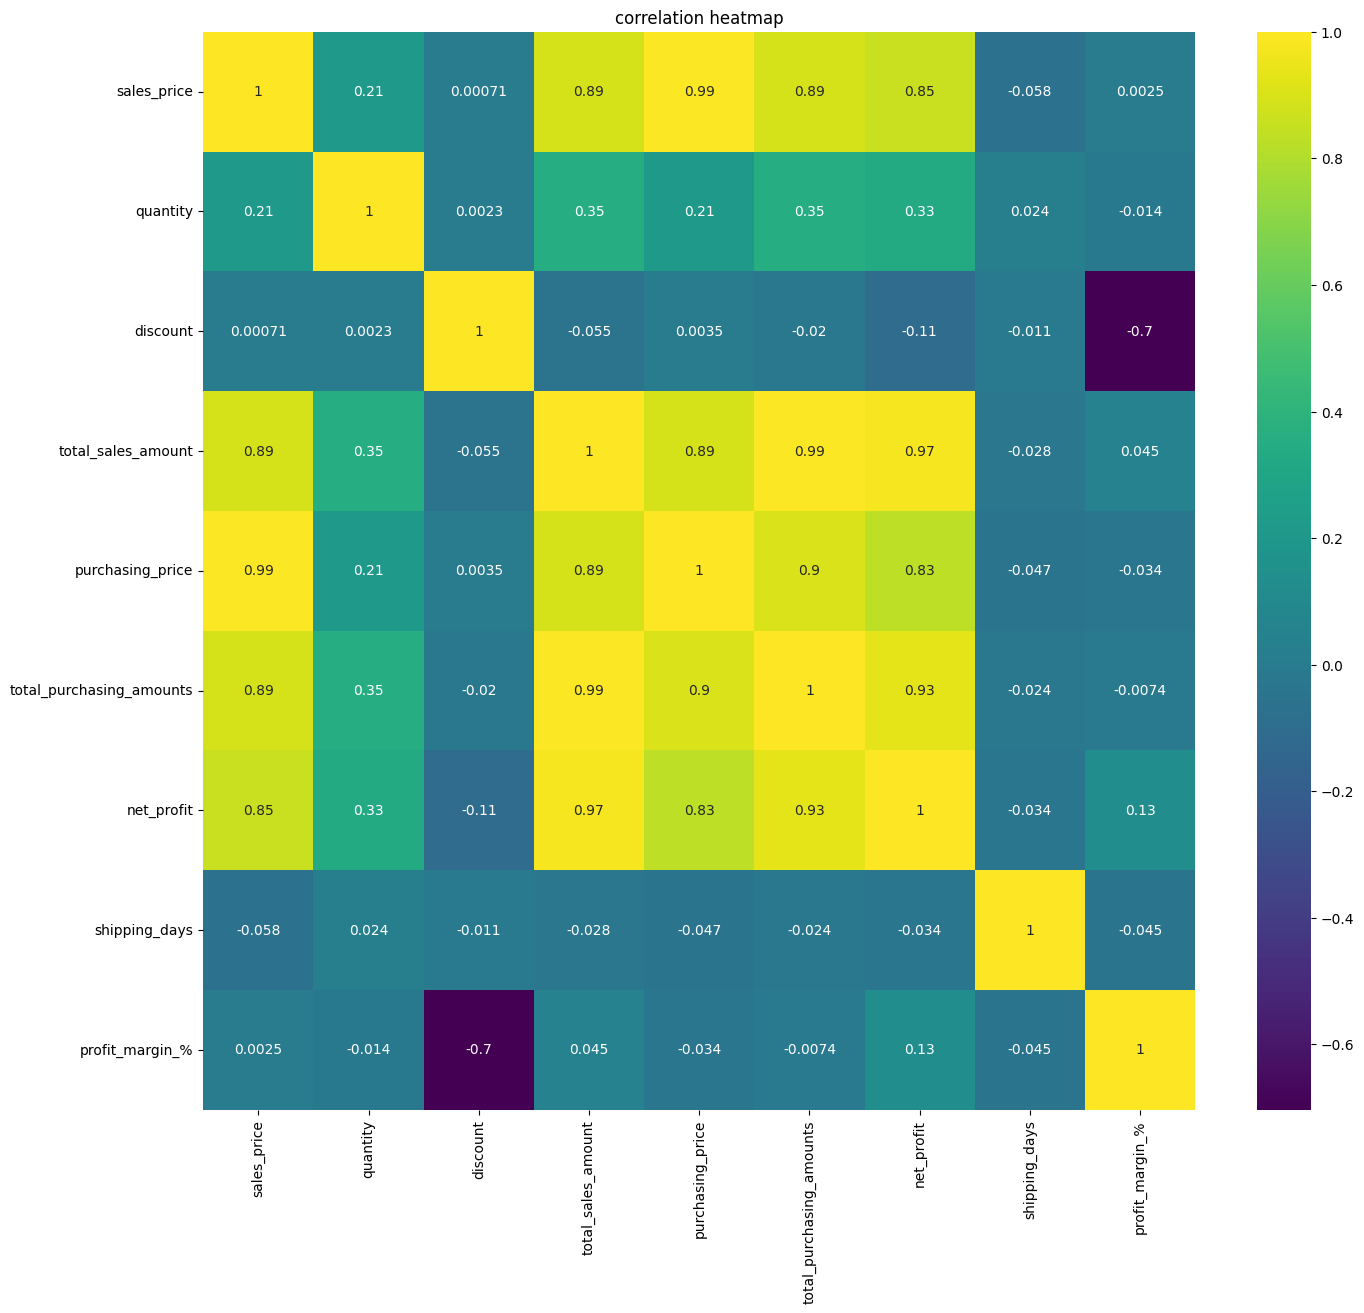

In [5]:
drop_col = df.drop(columns=['year' , 'postal_code'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlation heatmap")
plt.show()

**1. Strong positive relationships among price, cost, sales, and profit**

Sales Price, Purchasing Price, Total Sales Amount, Total Purchasing Amounts, and Net Profit are highly correlated (0.83 to 0.99).

**2. Discount strongly reduces profit margin**

Discount has a clear negative correlation of –0.7 with Profit Margin %.

**3. Shipping days and most other factors have almost no relationship**

Shipping Days shows near-zero correlation with every sales and profit metric. Profit Margin % itself is largely independent of Sales Price, Quantity, and costs (near zero), except for the strong negative link with Discount.

* show outliers 

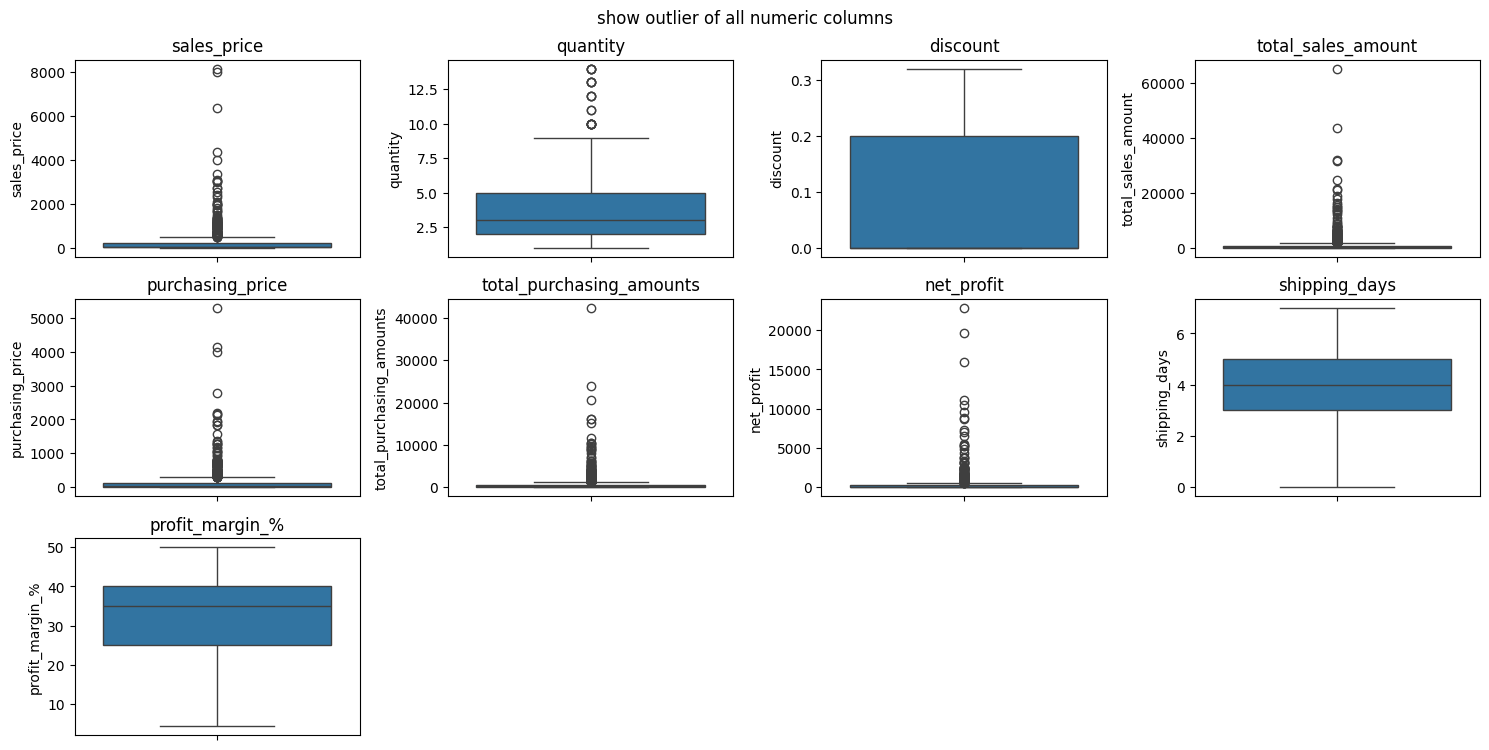

In [12]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.boxplot(df[col])
    plt.title(col)
plt.suptitle('show outlier of all numeric columns')
plt.tight_layout()
plt.show()

In [17]:
# how many outlier in column??
def detect_outliers(df , col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower_bound) | (df[col] > upper_bound))
    print(f"IQR method identified {outliers_iqr.sum()} outliers in {col}")
    return outliers_iqr

outlier_col = ['sales_price' , 'total_sales_amount' , 'purchasing_price' , 'total_purchasing_amounts']

for col in outlier_col:
    detect_outliers(df ,col)

IQR method identified 117 outliers in sales_price
IQR method identified 129 outliers in total_sales_amount
IQR method identified 122 outliers in purchasing_price
IQR method identified 128 outliers in total_purchasing_amounts


# analysis 📊

In [29]:
# 1 . KPI
overall_profit_margin = df['net_profit'].sum() / df['total_sales_amount'].sum() * 100
print(f'overall profit margin {overall_profit_margin.round(2)}%')

tota_sales = df['total_sales_amount'].sum()
print(f'overall sales {tota_sales.round(2)}')

overall_purchase_amount = df['total_purchasing_amounts'].sum()
print(f'overall purchase amount {overall_purchase_amount.round(2)}')

total_orders = df['order_id'].nunique()
print(f'total orders {total_orders}')

total_customers = df['customer_id'].nunique()
print(f'total customers {total_customers}')



overall profit margin 35.17%
overall sales 1116515.01
overall purchase amount 723863.9
total orders 488
total customers 366


**yearly net profit and total sale**

,total_net_profit
year,
2014,108999.60
2015,90329.20
2016,102445.66
2017,90876.64


,total_sale
year,
2014,323177.92
2015,255589.37
2016,286503.79
2017,251243.93


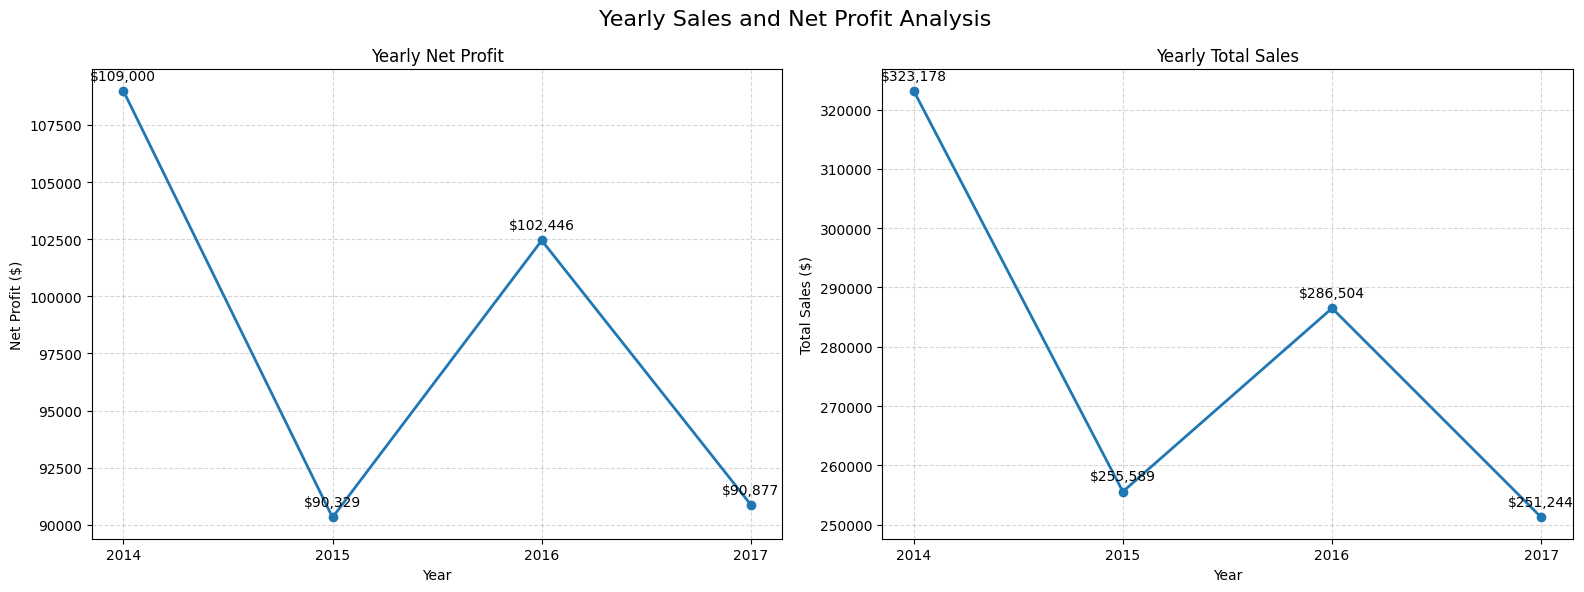

In [47]:
yearly_net_profit = df.groupby('year').agg(
    total_net_profit = ('net_profit' , 'sum')
)
yearly_net_profit = yearly_net_profit.sort_values(by='year')
display(yearly_net_profit.round(2))

yearly_total_sale = df.groupby('year').agg(
    total_sale = ('total_sales_amount' , 'sum')
)
yearly_total_sale = yearly_total_sale.sort_values(by='year')
display(yearly_total_sale.round(2))
# -------------------------------
# Create subplots
# -------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)


# =================================
# 1. Yearly Net Profit
# =================================
axes[0].plot(
    yearly_net_profit.index,
    yearly_net_profit['total_net_profit'],
    marker='o',
    linewidth=2
)

for year, profit in yearly_net_profit['total_net_profit'].items():
    axes[0].annotate(
        f'${profit:,.0f}',
        (year, profit),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

axes[0].set_title('Yearly Net Profit')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Net Profit ($)')
axes[0].set_xticks(yearly_net_profit.index)
axes[0].grid(
    True,
    linestyle='--',
    alpha=0.5
)


# =================================
# 2. Yearly Total Sales
# =================================
axes[1].plot(
    yearly_total_sale.index,
    yearly_total_sale['total_sale'],
    marker='o',
    linewidth=2
)

for year, sale in yearly_total_sale['total_sale'].items():
    axes[1].annotate(
        f'${sale:,.0f}',
        (year, sale),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

axes[1].set_title('Yearly Total Sales')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_xticks(yearly_total_sale.index)
axes[1].grid(
    True,
    linestyle='--',
    alpha=0.5
)


# Overall title
fig.suptitle(
    'Yearly Sales and Net Profit Analysis',
    fontsize=16
)

plt.tight_layout()
plt.show()

**region wise total sale and total net profit**

,total_sale,total_net_profit,total_orders
region,,,
West,341156.92,117765.99,152
Central,308258.67,104220.42,121
East,286321.21,101025.00,137
South,180778.22,69639.70,78


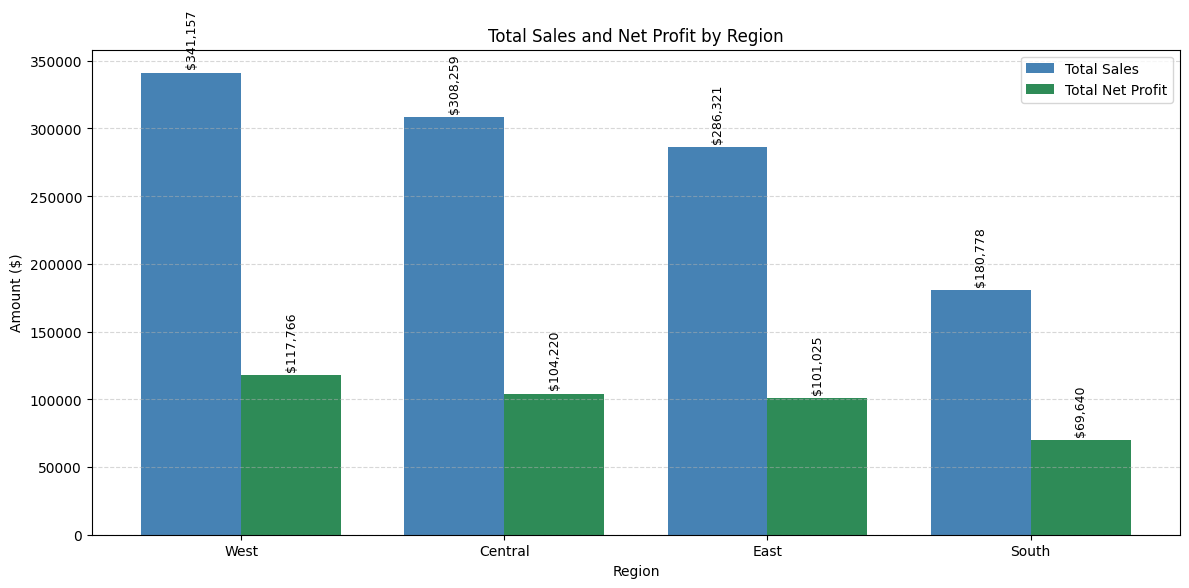

In [74]:
region_sale = df.groupby('region').agg(
    total_sale = ('total_sales_amount' , 'sum') , 
    total_net_profit = ('net_profit' , 'sum') , 
    total_orders = ('order_id' , 'nunique')
).sort_values(by='total_sale' , ascending=False)
display(region_sale.round(2))

x = np.arange(len(region_sale.index))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

sales_bars = ax.bar(
    x - bar_width / 2,
    region_sale['total_sale'],
    bar_width,
    label='Total Sales',
    color='steelblue'
)

profit_bars = ax.bar(
    x + bar_width / 2,
    region_sale['total_net_profit'],
    bar_width,
    label='Total Net Profit',
    color='seagreen'
)

for bars in (sales_bars, profit_bars):
    for bar in bars:
        value = bar.get_height()
        label_position = value if value >= 0 else 0
        vertical_alignment = 'bottom' if value >= 0 else 'top'
        ax.annotate(
            f'${value:,.0f}',
            (bar.get_x() + bar.get_width() / 2, label_position),
            xytext=(0, 3 if value >= 0 else -3),
            textcoords='offset points',
            ha='center',
            va=vertical_alignment,
            fontsize=9,
            rotation=90
        )

ax.set_title('Total Sales and Net Profit by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(region_sale.index)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**top 10 higest sale and net profitable state**

,total_sale,total_net_profit,total_order
state,,,
California,200615.23,67186.13,96
Texas,141770.46,46362.50,42
New York,133024.81,49632.47,60
Pennsylvania,96333.63,30590.69,30
Washington,59642.98,24898.04,22
Michigan,55658.63,22069.10,19
North Carolina,45533.80,19726.20,15
Illinois,42035.39,9014.76,30
Georgia,38382.84,13431.66,4


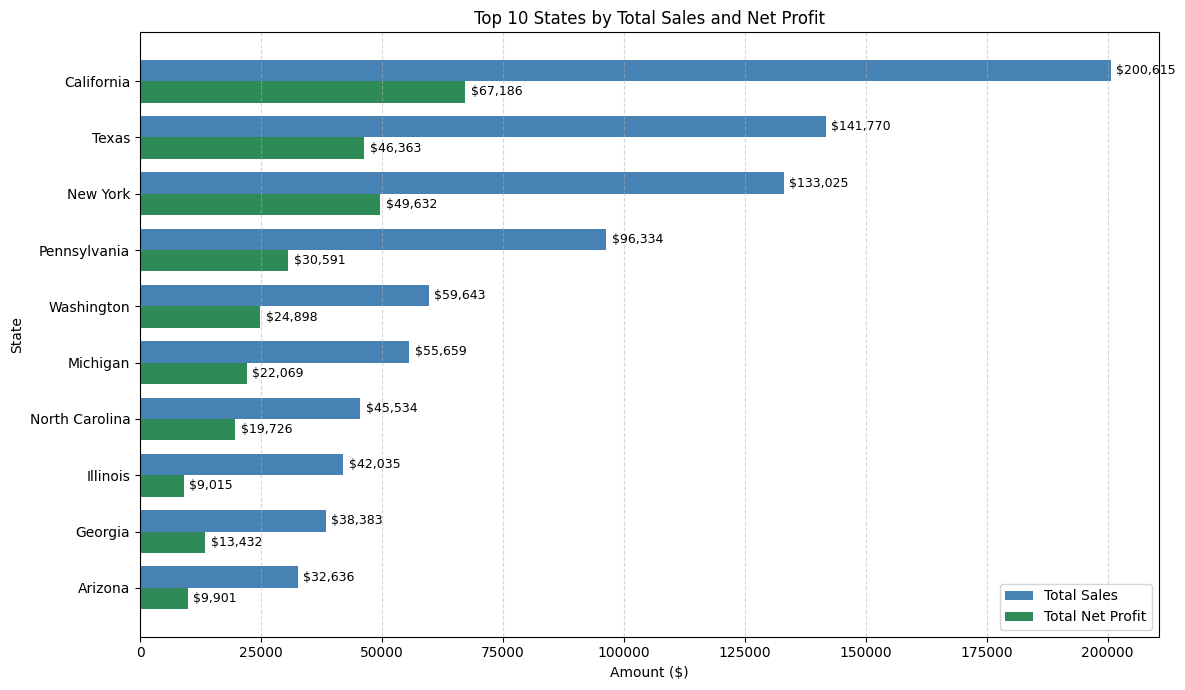

In [79]:
state_sale = df.groupby('state').agg(
    total_sale = ('total_sales_amount' , 'sum'),
    total_net_profit = ('net_profit' , 'sum'),
    total_order = ('order_id' , 'nunique')
).sort_values(by='total_sale' , ascending=False).head(10)
display(state_sale.round(2))

y = np.arange(len(state_sale.index))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(12, 7))

sales_bars = ax.barh(
    y - bar_height / 2,
    state_sale['total_sale'],
    bar_height,
    label='Total Sales',
    color='steelblue'
)

profit_bars = ax.barh(
    y + bar_height / 2,
    state_sale['total_net_profit'],
    bar_height,
    label='Total Net Profit',
    color='seagreen'
)

for bars in (sales_bars, profit_bars):
    for bar in bars:
        value = bar.get_width()
        label_position = value if value >= 0 else 0
        horizontal_alignment = 'left' if value >= 0 else 'right'
        ax.annotate(
            f'${value:,.0f}',
            (label_position, bar.get_y() + bar.get_height() / 2),
            xytext=(4 if value >= 0 else -4, 0),
            textcoords='offset points',
            ha=horizontal_alignment,
            va='center',
            fontsize=9
        )

ax.set_title('Top 10 States by Total Sales and Net Profit')
ax.set_xlabel('Amount ($)')
ax.set_ylabel('State')
ax.set_yticks(y)
ax.set_yticklabels(state_sale.index)
ax.invert_yaxis()
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**product category wise total sale and net profit**

,total_sale,total_net_profit,total_order,total_product
product_category,,,,
Technology,462915.90,170710.67,161,145
Furniture,350229.84,113917.38,170,150
Office Supplies,303369.26,108023.06,369,470


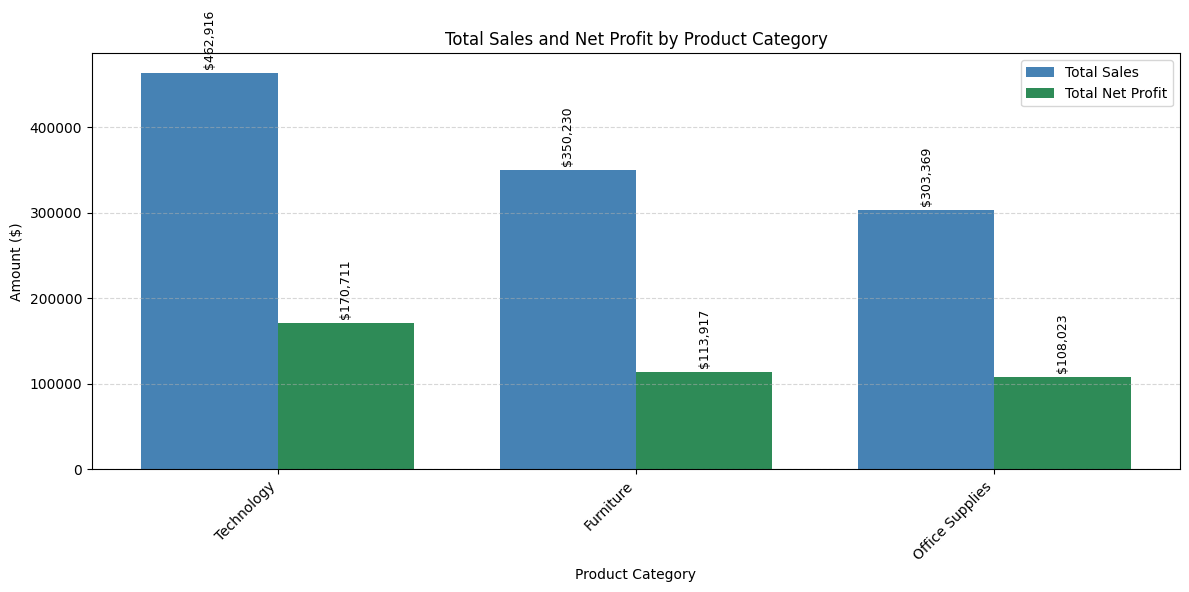

In [90]:
product_cat_sale = df.groupby('product_category').agg(
    total_sale = ('total_sales_amount' , 'sum'),
    total_net_profit = ('net_profit' , 'sum'),
    total_order = ('order_id' , 'nunique') , 
    total_product = ('product_id' , 'nunique')
).sort_values(by='total_sale' , ascending=False)
display(product_cat_sale.round(2))

x = np.arange(len(product_cat_sale.index))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

sales_bars = ax.bar(
    x - bar_width / 2,
    product_cat_sale['total_sale'],
    bar_width,
    label='Total Sales',
    color='steelblue'
)

profit_bars = ax.bar(
    x + bar_width / 2,
    product_cat_sale['total_net_profit'],
    bar_width,
    label='Total Net Profit',
    color='seagreen'
)

for bars in (sales_bars, profit_bars):
    for bar in bars:
        value = bar.get_height()
        label_position = value if value >= 0 else 0
        vertical_alignment = 'bottom' if value >= 0 else 'top'
        ax.annotate(
            f'${value:,.0f}',
            (bar.get_x() + bar.get_width() / 2, label_position),
            xytext=(0, 3 if value >= 0 else -3),
            textcoords='offset points',
            ha='center',
            va=vertical_alignment,
            fontsize=9,
            rotation=90
        )

ax.set_title('Total Sales and Net Profit by Product Category')
ax.set_xlabel('Product Category')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(product_cat_sale.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**sub category wise revenue and net profit ??**

,total_sales,total_net_profit,total_order,total_products
sub_category,,,,
Machines,155594.18,61252.88,12,11
Accessories,146302.37,59181.13,80,63
Tables,140626.34,51193.17,33,25
Phones,130443.90,40238.84,83,66
Binders,99532.39,38127.43,130,111
Chairs,98775.68,31658.95,52,38
Storage,92094.46,32960.64,89,73
Bookcases,64606.52,17259.49,18,16
Furnishings,46221.30,13805.77,88,71


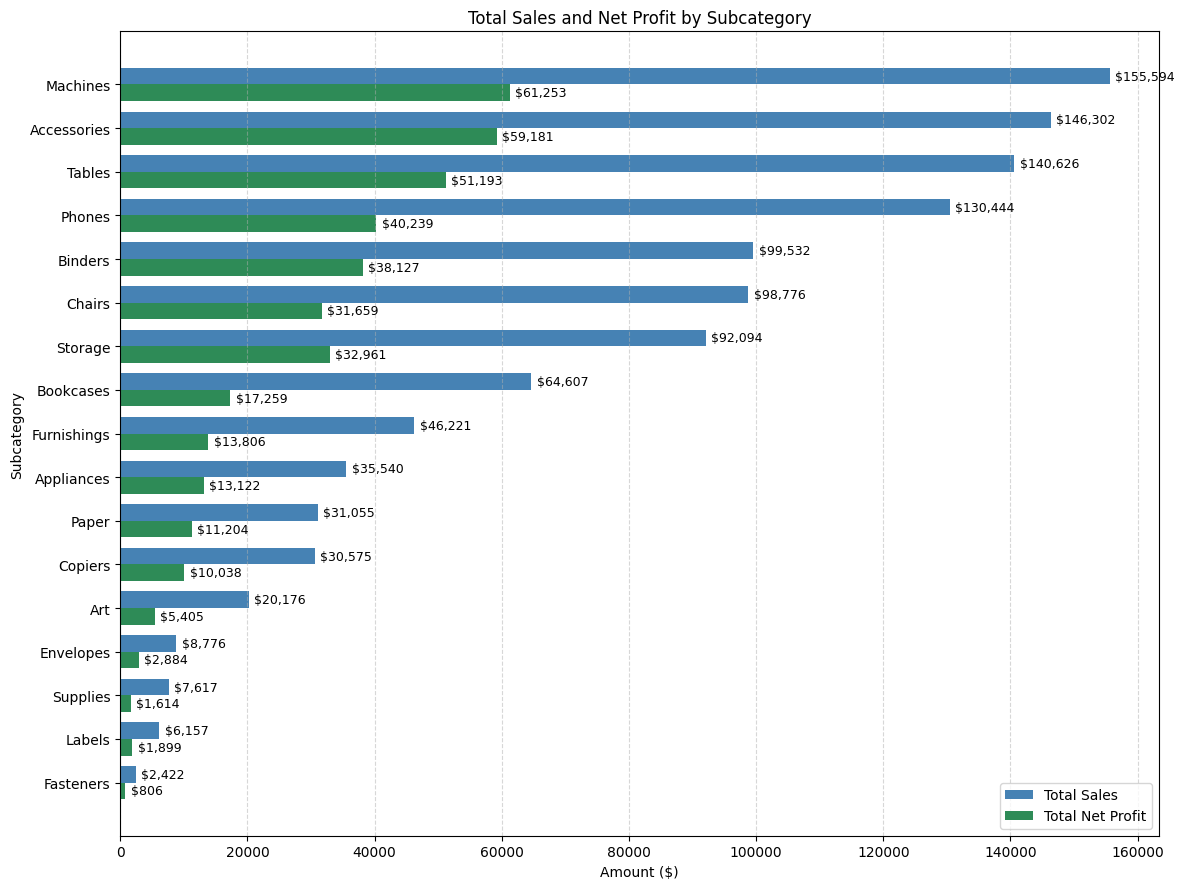

In [91]:
subcat_revenue = df.groupby('sub_category').agg(
    total_sales = ('total_sales_amount' , 'sum'),
    total_net_profit = ('net_profit' , 'sum'),
    total_order = ('order_id' , 'nunique') , 
    total_products = ('product_id' , 'nunique')
).sort_values(by='total_sales' , ascending=False)
display(subcat_revenue.round(2))

y = np.arange(len(subcat_revenue.index))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(12, 9))

sales_bars = ax.barh(
    y - bar_height / 2,
    subcat_revenue['total_sales'],
    bar_height,
    label='Total Sales',
    color='steelblue'
)

profit_bars = ax.barh(
    y + bar_height / 2,
    subcat_revenue['total_net_profit'],
    bar_height,
    label='Total Net Profit',
    color='seagreen'
)

for bars in (sales_bars, profit_bars):
    for bar in bars:
        value = bar.get_width()
        label_position = value if value >= 0 else 0
        horizontal_alignment = 'left' if value >= 0 else 'right'
        ax.annotate(
            f'${value:,.0f}',
            (label_position, bar.get_y() + bar.get_height() / 2),
            xytext=(4 if value >= 0 else -4, 0),
            textcoords='offset points',
            ha=horizontal_alignment,
            va='center',
            fontsize=9
        )

ax.set_title('Total Sales and Net Profit by Subcategory')
ax.set_xlabel('Amount ($)')
ax.set_ylabel('Subcategory')
ax.set_yticks(y)
ax.set_yticklabels(subcat_revenue.index)
ax.invert_yaxis()
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**top 10 higest total_purchasing_amount products**

In [72]:
product_purchase_amnt = df.groupby('product_name').agg(
    total_purchase_amount = ('total_purchasing_amounts' , 'sum')
).sort_values(by='total_purchase_amount' , ascending=False)
display(product_purchase_amnt.head(10))

,total_purchase_amount
product_name,
Lexmark MX611dhe Monochrome Laser Printer,52223.69280
Logitech P710e Mobile Speakerphone,25138.74870
"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",21339.09756
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,20653.58750
"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",16109.49600
Cubify CubeX 3D Printer Triple Head Print,15999.96000
Bevis 36 x 72 Conference Tables,12386.75500
"Bevis Round Bullnose 29"" High Table Top",11593.45440
Apple iPhone 5S,11490.99840


**customer segment analysis**

In [88]:
client_segment = df.groupby('client_segment').agg(
    total_sale = ('total_sales_amount' , 'sum') , 
    net_profit = ('net_profit' , 'sum') , 
    total_customer = ('customer_id' , 'nunique') , 
    total_orders = ('order_id' , 'nunique')
).sort_values(by='total_sale',ascending=False)
display(client_segment)

,total_sale,net_profit,total_customer,total_orders
client_segment,,,,
Consumer,591565.40649,202934.77998,195,264
Corporate,305427.90100,114791.07005,111,149
Home Office,219521.70455,74925.25760,60,75


**shiping mode analysis**

In [ ]:
shipping_mode = df.groupby('ship_mode').agg(
    total_order = ('order_id' , 'nunique') , 
    total_customers = ('customer_id' , 'nunique') , 
    avg_ship_day = ('shipping_days' , 'mean')
).sort_values(by='total_order' , ascending=False)
display(shipping_mode)

,total_order,total_customers,avg_ship_day
ship_mode,,,
Standard Class,286,243,5.011966
Second Class,104,97,3.193548
First Class,87,82,2.210811
Same Day,11,11,0.000000
